# 02. Engenharia de features

**Fase CRISP-DM:** 3, *Data Preparation*.
**Entregáveis:** dataset final versionado, catálogo de features com fórmula, motivação e risco de vazamento, e código de preparação reproduzível.

Este notebook narra as decisões. A construção mora em [`src/preprocessing/feature_store.py`](../src/preprocessing/feature_store.py) e [`build_dataset.py`](../src/preprocessing/build_dataset.py), o contrato de colunas em [`pipeline.py`](../src/preprocessing/pipeline.py) e as medições em [`diagnostico.py`](../src/preprocessing/diagnostico.py).

| Pergunta | Decisão que ela fecha |
|---|---|
| A coalescência `5 → 3` cobre quanto da coorte? | usar ou não o agregado do INEP como fonte de lag |
| Qual feature tem sinal, e qual tem sinal demais? | lista de features e alarme de vazamento |
| `id_escola` é a mesma escola nos dois anos? | manter ou não o bloco `esc_*` |
| A matriz é inversível? | o que vai ao baseline linear |
| Os percentis do microdado se pagam? | réplica do experimento B5 |

> **Status de validação:** evidência retrospectiva e exploratória. A seleção supervisionada de atributos consultou a coorte inteira de 2024, então a reserva de teste não é independente dessa seleção, e não há validação temporal do campeão. O status está fixado em `src/evaluation/protocolo.py`; os limites do trabalho estão no `README.md` e a proveniência temporal de cada atributo em `reports/contrato_temporal.md`.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src import config, eda
from src.data import loader
from src.preprocessing import build_dataset, diagnostico, feature_store as fs, pipeline as pl
from src.visualization import plots_features as plots

eda.aplicar_estilo()
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 60)

print("interpretador", sys.executable)
print("RANDOM_STATE ", config.RANDOM_STATE, "| k da suavizacao", fs.K_SUAVIZACAO)

interpretador C:\Users\Vyctor\Documents\pos-tech\fase-3\Fase3_TechChallenge-Predicao-Inteligencia-Analitica-para-Alfabetizacao-no-Brasil\.venv\Scripts\python.exe
RANDOM_STATE  42 | k da suavizacao 30.0


---
## 1. A feature store de 2023

**Pergunta:** as quatro fontes cobrem quanto da coorte de 2024, e com qual fidelidade de apuração?
**Decisão:** usar ou não o agregado do INEP como fonte de lag, e se a coluna de proveniência é necessária.

In [2]:
store = fs.montar_feature_store()
for nivel, quadro in store.items():
    print(f"{nivel:10s} {quadro.shape[0]:6d} unidades x {quadro.shape[1]:2d} colunas")

print("\nmunicipios por fonte do valor coalescido:")
print(store["municipio"]["fonte_lag_municipal"].value_counts().to_string())
print("\nUFs por fonte:")
print(store["uf"]["fonte_lag_uf"].value_counts().to_string())

escola      36525 unidades x  9 colunas
municipio    5498 unidades x 15 colunas
uf             24 unidades x  6 colunas

municipios por fonte do valor coalescido:
fonte_lag_municipal
gold           4871
agregado_r3     548
agregado_r5      79

UFs por fonte:
fonte_lag_uf
gold           23
agregado_r5     1


**Achado 1, quatro fontes e três níveis.** A feature store tem 36.525 escolas, **5.498 municípios** e **24 UFs**. Dos municípios, 4.871 vêm da Gold de 2023, 79 do agregado do INEP na rede 5 e 548 na rede 3 — a coalescência prevista em B4. No grão UF a Gold tem 23 e o agregado acrescenta uma: **São Paulo**, que sozinha é 21,35% da coorte de 2024. Acre e Distrito Federal não existem em nenhuma fonte de 2023 e ficam sem lag de UF.

Sem a coluna de proveniência, essas três apurações — com fidelidades medidas de 0,05pp, 0,99pp e 1,73pp contra o microdado — conviveriam na mesma coluna sem rastro.

---
## 2. O dataset de modelagem

**Pergunta:** a coorte sai do join com as linhas com que entrou, e sem as 936 sem medida?
**Decisão:** aceitar ou não o dataset como base das Etapas 4 a 6.

Gold 2024                    1852788 linhas
preenchimento_caderno = 0        936 removidas
dataset de modelagem         1851852 x 41 colunas

taxa de risco (nao alfabetizacao) 0.4022


memoria 815 MB
images/features/01_cobertura_por_fonte.png


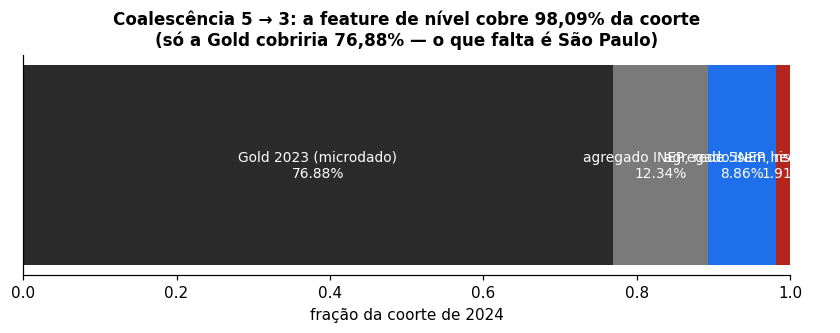

In [3]:
gold_bruta = loader.carregar_gold(ano=config.ANO_ALVO, colunas=["preenchimento_caderno"])
dados = loader.carregar_dataset_modelagem()

print(f"Gold 2024                  {len(gold_bruta):>9d} linhas")
print(f"preenchimento_caderno = 0  {int((gold_bruta['preenchimento_caderno'] == 0).sum()):>9d} removidas")
print(f"dataset de modelagem       {len(dados):>9d} x {dados.shape[1]} colunas")
print(f"\ntaxa de risco (nao alfabetizacao) {dados[config.TARGET].mean():.4f}")
print(f"memoria {dados.memory_usage(deep=True).sum() / 2**20:.0f} MB")

fig = plots.plotar_cobertura_por_fonte(dados["fonte_lag_municipal"])
print(plots.salvar_figura(fig, "01_cobertura_por_fonte"))

In [4]:
colunas = ["mun_taxa_alfab_lag1", "mun_media_portugues_lag1", "mun_meta_2024_lag1",
           "mun_prof_p50_lag1", "mun_taxa_presenca_lag1", "uf_taxa_alfab_lag1", "esc_taxa_alfab_lag1"]
display(pd.DataFrame({"cobertura": dados[colunas].notna().mean()}).round(4))

print("risco por tem_historico_municipio:")
display(dados.groupby("tem_historico_municipio")[config.TARGET].agg(["size", "mean"]).round(4))
print("UFs sem lag de UF:", sorted(set(dados.loc[dados["uf_taxa_alfab_lag1"].isna(), "sigla_uf"])))

,cobertura
mun_taxa_alfab_lag1,0.9809
mun_media_portugues_lag1,0.9809
mun_meta_2024_lag1,0.9533
mun_prof_p50_lag1,0.7688
mun_taxa_presenca_lag1,0.7688
uf_taxa_alfab_lag1,0.9825
esc_taxa_alfab_lag1,0.7897


risco por tem_historico_municipio:


,size,mean
tem_historico_municipio,,
0,428119,0.4154
1,1423733,0.3982


UFs sem lag de UF: ['AC', 'DF']


**Achado 2, a coalescência compra São Paulo.** O dataset sai com **1.851.852 linhas**, as 936 sem medida removidas, e taxa de risco de 0,4022. As features de **nível** cobrem 98,09% da coorte; as **distribucionais**, que exigem grão aluno e por isso só existem na Gold, cobrem 76,88%. É a diferença entre ter e não ter feature para um quinto do país.

O risco médio de quem não tem histórico municipal é 0,4154 contra 0,3982 de quem tem. A diferença de 1,7pp confirma o que a auditoria já dizia (B3): o gap é de **cobertura de feature**, não um atalho para o alvo. Mas ele é SP, DF e AC inteiros, então `tem_historico_municipio` é quase um indicador de UF — e toda métrica da Etapa 4 tem de vir estratificada por ele.

---
## 3. Dicionário de features

**Pergunta:** o que tem sinal, o que não tem, e o que tem sinal demais?
**Decisão:** a lista final de features, e o alarme de vazamento antes de qualquer tuning.

,feature,bloco,tipo,cobertura,n_unicos,auc,forca
0,mun_prof_p75_lag1,município (microdado),numérica,0.7688,4771,0.3421,0.1579
1,mun_prof_p50_lag1,município (microdado),numérica,0.7688,4806,0.3463,0.1537
2,mun_prof_p25_lag1,município (microdado),numérica,0.7688,4837,0.3516,0.1484
3,mun_media_portugues_lag1,município,numérica,0.9809,5447,0.3589,0.1411
4,mun_taxa_alfab_lag1,município,numérica,0.9809,5296,0.3638,0.1362
5,mun_meta_2024_lag1,município,numérica,0.9533,2745,0.3699,0.1301
6,mun_nivel_alfabetizacao_lag1,município,numérica,0.9533,6,0.3752,0.1248
7,uf_media_portugues_lag1,UF,numérica,0.9825,24,0.3825,0.1175
8,uf_taxa_alfab_lag1,UF,numérica,0.9825,24,0.3951,0.1049
9,esc_taxa_alfab_lag1_suav,escola (controle),numérica,0.9809,35458,0.3955,0.1045


images/features/02_auc_univariada.png


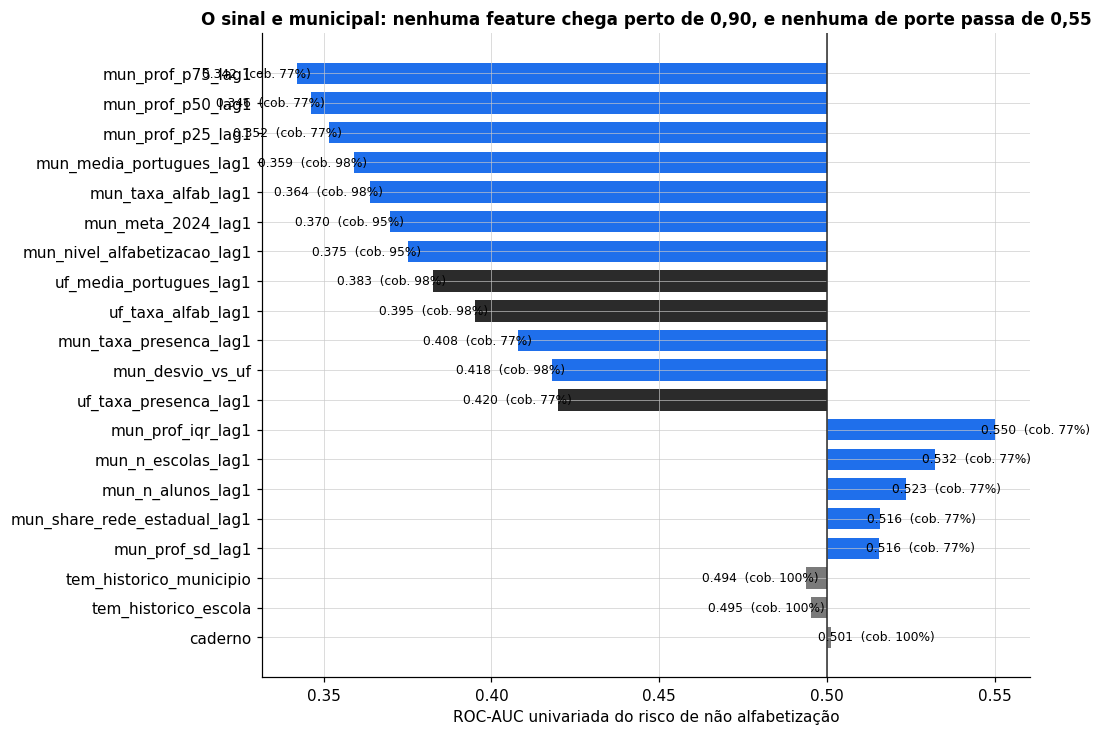

In [5]:
dicionario = diagnostico.medir_dicionario(dados)
display(dicionario.round(4))

fig = plots.plotar_auc_univariada(
    dicionario[dicionario["bloco"] != "escola (controle)"],
    "O sinal e municipal: nenhuma feature chega perto de 0,90, e nenhuma de porte passa de 0,55",
)
print(plots.salvar_figura(fig, "02_auc_univariada"))

**Achado 3, o sinal é municipal e nenhuma feature vaza.** As nove primeiras colocações são todas de município ou de UF. A melhor é `mun_prof_p75_lag1`, com AUC 0,658 de alfabetização, e a melhor com cobertura acima de 98% é `mun_media_portugues_lag1`, com 0,641.

Duas leituras na direção oposta. Nenhuma feature chega perto de 0,90, que é o resultado esperado quando toda coluna vem do ano anterior — se alguma tivesse chegado, seria vazamento, não qualidade. E porte e dispersão continuam colados em 0,5: `mun_n_alunos_lag1` em 0,4765, `mun_prof_sd_lag1` em 0,4844.

O `caderno` marca **0,5013**, exatamente o que se espera de um instrumento randomizado. É o valor de referência do controle negativo: se ele subir no SHAP da Etapa 5, o alarme é de sobreajuste.

---
## 4. `id_escola` não é chave longitudinal

**Pergunta:** o `id_escola` de 2023 e o de 2024 são a mesma escola?
**Decisão:** manter ou não o bloco `esc_*` entre as features do modelo.

O teste é o mais simples possível e não depende de modelo: escola não muda de município.

In [6]:
g23 = loader.carregar_gold(ano=2023, colunas=["id_escola", "id_municipio"])
g24 = loader.carregar_gold(ano=2024, colunas=["id_escola", "id_municipio"])
dim = loader.carregar_dim_municipio().set_index("id_municipio")["sigla_uf"]

par = pd.concat(
    [g23.groupby("id_escola")["id_municipio"].first().rename("m23"),
     g24.groupby("id_escola")["id_municipio"].first().rename("m24")],
    axis=1, join="inner",
)
mesma_uf = dim.reindex(par["m23"]).to_numpy() == dim.reindex(par["m24"]).to_numpy()
print(f"id_escola em 2023: {g23['id_escola'].nunique():d} | em 2024: {g24['id_escola'].nunique():d} | nos dois: {len(par):d}")
print(f"...e no mesmo municipio: {float((par['m23'] == par['m24']).mean()):.4%}")
print(f"...e na mesma UF:        {float(mesma_uf.mean()):.4%}")

falsos = set(par.index[par["m23"] != par["m24"]])
print(f"alunos de 2024 que receberiam o agregado de OUTRA escola: {int(g24['id_escola'].isin(falsos).sum()):d}"
      f" ({float(g24['id_escola'].isin(falsos).mean()):.2%})")
print("\nexemplo do deslocamento do identificador:")
display(par[par["m23"] != par["m24"]].head(6))

id_escola em 2023: 36525 | em 2024: 42328 | nos dois: 36051
...e no mesmo municipio: 2.3966%
...e na mesma UF:        80.6302%
alunos de 2024 que receberiam o agregado de OUTRA escola: 1414592 (76.35%)

exemplo do deslocamento do identificador:


,m23,m24
id_escola,,
60000046,1100700,1100338
60000048,1100809,1100700
60000049,1101104,1100809
60000051,1100080,1101104
60000052,1101492,1100080
60000053,1100106,1101492


{'real': 0.5581, 'dentro_uf': 0.5601, 'dentro_uf_dp': 0.0006, 'global': 0.4998, 'municipal': 0.6362}
images/features/03_controle_embaralhamento_escola.png


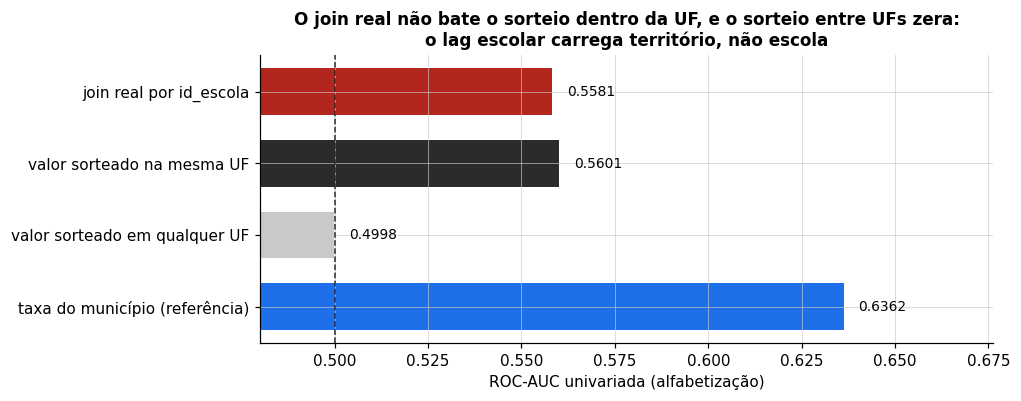

In [7]:
controle = diagnostico.medir_controle_embaralhamento(dados)
print({k: round(v, 4) for k, v in controle.items()})

fig = plots.plotar_controle_embaralhamento(controle)
print(plots.salvar_figura(fig, "03_controle_embaralhamento_escola"))

**Achado 4, e a maior correção desta etapa: `id_escola` não é chave longitudinal.**

Dos 36.051 identificadores presentes nos dois anos, só **2,3966%** apontam para o mesmo município — e escola não muda de município. O identificador é reatribuído a cada edição em ordem territorial, exatamente como `id_aluno` (A2): a tabela acima mostra o deslocamento posição a posição. Na prática, **1.414.592 alunos de 2024, ou 76,35% da coorte, receberiam pelo join o histórico de outra escola**, quase sempre da mesma UF (80,63%).

O controle de embaralhamento fecha o argumento. Sortear um valor qualquer dentro da mesma UF entrega AUC **0,5601**, igual ou acima dos **0,5581** do join real, com desvio de 0,0006 entre seeds; sortear de qualquer UF derruba para **0,4998**, o acaso exato. Tudo o que a taxa "da escola" carrega é recuperável sorteando uma escola qualquer do mesmo estado.

**Decisão:** o bloco `esc_*` sai de `FEATURES_MODELO` e fica como **controle negativo declarado**, ao lado do `caderno`. A ablação multivariada da seção 8 confirma pelo outro lado: acrescentá-lo custa −0,0004 de ROC-AUC.

Isso não invalida a EDA — reforça a conclusão dela. O notebook 01 mediu persistência escolar de 0,258 e concluiu "o sinal é territorial, não escolar". Estava certo, por um motivo mais forte do que sabia: não é que a escola tenha pouco sinal, é que a escola nunca foi medida.

---
## 5. Colinearidade e o subconjunto podado

**Pergunta:** a matriz do conjunto completo é inversível?
**Decisão:** o que vai ao baseline linear da Etapa 4 e o que só o LightGBM recebe.

In [8]:
amostra = dados.sample(300_000, random_state=config.RANDOM_STATE)

numericas_completas = [c for c in pl.FEATURES_MODELO if c not in pl.COLS_CATEGORICAS + pl.COLS_CATEGORICAS_RARAS]
X_completo = amostra[numericas_completas].fillna(amostra[numericas_completas].median())
print("VIF do conjunto completo (10 maiores):")
display(pl.medir_vif(X_completo).head(10).round(2))

X_podado, y_podado, _ = pl.separar_X_y(amostra, pl.FEATURES_PODADAS)
numericas_podadas = [c for c in pl.FEATURES_PODADAS if c not in pl.COLS_CATEGORICAS]
transformado = pl.montar_pre_processador(pl.FEATURES_PODADAS, indicador_de_nulo=False).fit_transform(X_podado)
print("VIF do subconjunto podado, ja pre-processado:")
display(pl.medir_vif(pd.DataFrame(transformado[:, :len(numericas_podadas)], columns=numericas_podadas)).round(2))

VIF do conjunto completo (10 maiores):


,feature,vif
0,mun_taxa_alfab_lag1,1289.12
9,uf_taxa_alfab_lag1,660.19
8,mun_desvio_vs_uf,590.16
6,mun_n_escolas_lag1,61.06
5,mun_n_alunos_lag1,60.68
3,mun_meta_2024_lag1,24.74
10,uf_media_portugues_lag1,24.63
1,mun_media_portugues_lag1,23.43
2,mun_nivel_alfabetizacao_lag1,16.71
12,tem_historico_municipio,5.39


VIF do subconjunto podado, ja pre-processado:


,feature,vif
0,mun_taxa_alfab_lag1,2.20
4,uf_taxa_alfab_lag1,2.15
1,mun_taxa_presenca_lag1,1.20
5,tem_historico_municipio,1.15
3,mun_share_rede_estadual_lag1,1.10
2,mun_n_alunos_lag1,1.10


**Achado 5, a matriz do conjunto completo é singular por construção.** O VIF de `mun_taxa_alfab_lag1` chega a **1289**, e o de `mun_desvio_vs_uf` a 590, porque `mun_desvio_vs_uf = mun_taxa − uf_taxa` é combinação linear exata das outras duas. Não é multicolinearidade alta: é dependência perfeita.

O subconjunto podado, com uma métrica de nível por território, deixa o maior VIF em **2,20**, abaixo do limite de 3 da checklist. `sigla_uf` fica de fora porque `uf_taxa_alfab_lag1` já é o efeito de UF numa coluna contínua. O LightGBM pode receber o conjunto inteiro; a regressão logística, não.

---
## 6. O pipeline

**Pergunta:** o que de fato chega ao estimador, e o `caderno = 43` quebra alguma coisa?
**Decisão:** os parâmetros do `OneHotEncoder` e do imputador.

In [9]:
X, y, grupos = pl.separar_X_y(dados)
pre = pl.montar_pre_processador().fit(X.sample(300_000, random_state=config.RANDOM_STATE))
nomes = list(pre.get_feature_names_out())

print(f"{X.shape[1]} colunas de entrada -> {len(nomes)} colunas no estimador")
print("caderno_43 entre elas:", "caderno_43" in nomes, "| caderno_infrequent_sklearn:", "caderno_infrequent_sklearn" in nomes)
print("UFs pequenas preservadas:", all(f"sigla_uf_{uf}" in nomes for uf in ("SE", "TO", "AP", "AC")))

indicadores = [c for c in nomes if c.startswith("missingindicator_")]
padroes = amostra[[c.replace("missingindicator_", "") for c in indicadores]].isna().T.drop_duplicates()
print(f"indicadores de nulo: {len(indicadores)} | padroes de nulidade distintos entre eles: {len(padroes)}")

20 colunas de entrada -> 89 colunas no estimador
caderno_43 entre elas: False | caderno_infrequent_sklearn: True
UFs pequenas preservadas: True


indicadores de nulo: 12 | padroes de nulidade distintos entre eles: 5


**Achado 6, e uma correção ao plano.** As 20 colunas de entrada viram **89** no estimador. O `caderno = 43`, com 12 alunos e ausente de 2023, é absorvido por `caderno_infrequent_sklearn`, como o plano previa.

O que o plano não previu: aplicar `min_frequency=0,01` a **todas** as categóricas colapsaria SE, TO, AP e AC — as quatro UFs abaixo de 1% da coorte, com 10 a 18 mil alunos cada — justamente na variável de 49pp de amplitude. O limiar ficou restrito ao `caderno`, e as duas configurações estão travadas por teste.

Os 12 indicadores de nulo colapsam em **5** padrões distintos: as colunas municipais somem em bloco. Eles ficam, porque `add_indicator=True` é a defesa correta contra uma coluna futura cuja nulidade não seja em bloco, mas a Etapa 5 precisa lê-los como família — e o baseline linear os desliga, senão a matriz volta a ser singular.

---
## 7. Asserções anti-leakage do dataset

**Pergunta:** alguma coluna proibida sobreviveu ao join?
**Decisão:** liberar ou não o dataset para a Etapa 4.

In [10]:
print("intersecao X ∩ COLS_PROIBIDAS:", set(X.columns) & set(config.COLS_PROIBIDAS))
print("intersecao X ∩ colunas operacionais:", set(X.columns) & set(pl.COLS_OPERACIONAIS))
print("colunas do dataset fora de X:", sorted(set(dados.columns) - set(X.columns)))

correlacao = X.select_dtypes("number").corrwith(y, method="spearman").abs().sort_values(ascending=False)
print(f"\nmaior |Spearman| com o alvo: {correlacao.iloc[0]:.4f} ({correlacao.index[0]}) — limite da checklist: 0,95")

taxa_2024 = fs.agregados_municipais_ponderados(config.ANO_ALVO).set_index("id_municipio")
comparacao = pd.concat(
    [store["municipio"]["mun_taxa_alfab_lag1"], taxa_2024["taxa_alfab_ponderada"] * 100], axis=1
).dropna()
print(f"MAE entre a feature e a taxa de 2024: {float((comparacao.iloc[:, 0] - comparacao.iloc[:, 1]).abs().mean()):.3f}pp"
      f" (corr {float(comparacao.corr().iloc[0, 1]):.3f}) — a feature e de 2023, nao do ano do alvo")

intersecao X ∩ COLS_PROIBIDAS: set()
intersecao X ∩ colunas operacionais: set()
colunas do dataset fora de X: ['esc_n_alunos_lag1', 'esc_n_matriculados_lag1', 'esc_prof_iqr_lag1', 'esc_prof_p25_lag1', 'esc_prof_p50_lag1', 'esc_prof_p75_lag1', 'esc_prof_sd_lag1', 'esc_taxa_alfab_lag1', 'esc_taxa_alfab_lag1_suav', 'esc_taxa_presenca_lag1', 'id_municipio', 'mun_n_matriculados_lag1', 'mun_prof_iqr_lag1', 'mun_prof_p25_lag1', 'mun_prof_p50_lag1', 'mun_prof_p75_lag1', 'mun_prof_sd_lag1', 'peso_aluno', 'risco_nao_alfabetizacao', 'uf_n_alunos_lag1', 'uf_n_matriculados_lag1']



maior |Spearman| com o alvo: 0.2397 (mun_media_portugues_lag1) — limite da checklist: 0,95


MAE entre a feature e a taxa de 2024: 12.360pp (corr 0.637) — a feature e de 2023, nao do ano do alvo


**Achado 7, as asserções passam.** Interseção vazia com `COLS_PROIBIDAS` e com as colunas operacionais. A maior correlação de Spearman com o alvo dentro de `X` é **0,240**, e 0,268 no dataset inteiro, contra o limite de 0,95 — uma ordem de grandeza de folga.

E a prova direta de que a feature é do ano certo: `mun_taxa_alfab_lag1` reproduz a taxa ponderada de 2023 exatamente e difere da de 2024 por **12,36pp** de MAE, com correlação de 0,637 — que é a persistência municipal medida na EDA, não uma cópia do alvo.

`peso_aluno` e `id_municipio` ficam no arquivo e fora de `X`: um é peso de agregação populacional (B2), o outro é o grupo de CV.

---
## 8. Réplica do experimento B5

**Pergunta:** os percentis de proficiência do microdado se pagam fora de um único split?
**Decisão:** manter ou cortar o único bloco de features que depende do microdado.

Gerado por [`scripts/experimento_b5.py`](../scripts/experimento_b5.py): `StratifiedGroupKFold(5)` por município, 3 seeds, folds compartilhados entre os conjuntos, hiperparâmetros fixos.

,conjunto,n_features,roc_auc,dp_entre_folds,minimo,maximo,pr_auc
0,A_sem_percentis,20,0.6589,0.0135,0.6386,0.6811,0.5468
1,B_com_percentis,25,0.6593,0.0134,0.6387,0.6814,0.5472
2,C_com_escola,34,0.6589,0.0134,0.6379,0.6807,0.5466


,base,alternativo,n_folds,delta_medio,delta_dp,folds_a_favor,ic95_baixo,ic95_alto,t_nadeau_bengio,p_valor
0,A_sem_percentis,B_com_percentis,15,0.0004,0.0010,10,-0.0008,0.0015,0.6723,0.5123
1,B_com_percentis,C_com_escola,15,-0.0004,0.0007,4,-0.0013,0.0005,-0.9364,0.3649


images/features/04_replica_experimento_b5.png


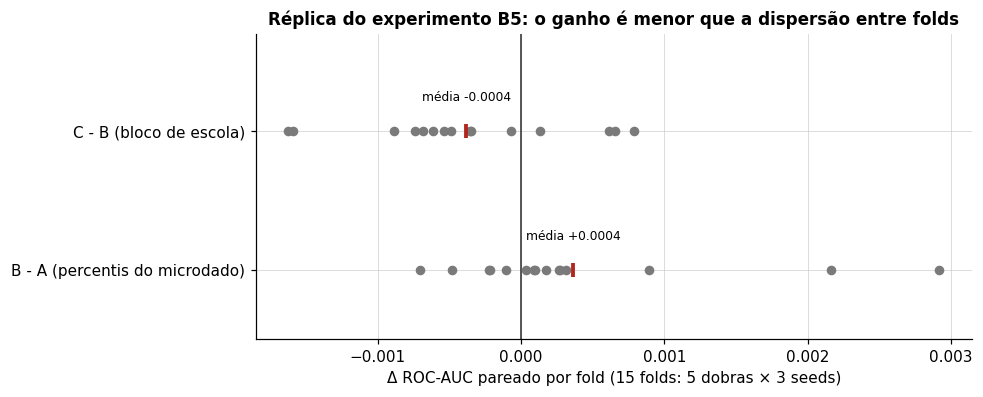

In [11]:
replica = pd.read_csv(config.DIR_METRICS / "experimento_b5_replica.csv")
display(diagnostico.resumir_replica(replica).round(4))

comparacoes = pd.DataFrame([
    diagnostico.comparar_pareado(replica, "A_sem_percentis", "B_com_percentis"),
    diagnostico.comparar_pareado(replica, "B_com_percentis", "C_com_escola"),
])
display(comparacoes.round(4))

largo = replica.pivot_table(index=["seed", "fold"], columns="conjunto", values="roc_auc")
deltas = pd.DataFrame({
    "B - A (percentis do microdado)": largo["B_com_percentis"] - largo["A_sem_percentis"],
    "C - B (bloco de escola)": largo["C_com_escola"] - largo["B_com_percentis"],
})
fig = plots.plotar_replica_b5(deltas)
print(plots.salvar_figura(fig, "04_replica_experimento_b5"))

**Achado 8, e a decisão que estava pendente desde a Etapa 2.5.**

Os três conjuntos empatam em **0,659** de ROC-AUC, com desvio de 0,0134 entre folds. Os percentis do microdado somam **+0,0004**, com IC95 pareado de [−0,0008; +0,0015], t de Nadeau-Bengio 0,67 e p 0,51. O bloco de escola **subtrai** 0,0004, com 4 folds a favor em 15.

O ganho medido pela auditoria num único split era +0,0022. A réplica devolve um sexto disso, com o intervalo cruzando o zero — que é exatamente por que a réplica estava na checklist, e não uma formalidade.

**Decisão: os percentis saem de `FEATURES_MODELO`.** O efeito é 36 vezes menor que a dispersão entre folds; as cinco colunas cobrem 76,88% contra os 98,09% de `mun_media_portugues_lag1`, que mede a mesma distribuição; e faltam precisamente para SP, DF e AC. Ficam construídas e gravadas no dataset — reabrir é uma linha, `FEATURES_MODELO + FEATURES_PERCENTIS_MICRODADO`.

Isso **não** dispensa o microdado: ele segue obrigatório por `peso_aluno` e `presenca`. O que sai é o único bloco que só ele produz.

---
## Síntese

**O que a Etapa 4 recebe:** `data/processed/dataset_2024.parquet`, 1.851.852 alunos de 2024 e 41 colunas, das quais **20 são features**, todas derivadas exclusivamente de 2023.

| Bloco | Colunas | Papel |
|---|---|---|
| município | 9 | onde está o sinal; nível coberto em 98,09% |
| UF | 3 | contexto; sem AC e DF, que não existem em 2023 |
| cobertura do lag | 4 | `tem_historico_*` e as duas colunas de proveniência |
| estrutural | 4 | rede, região, UF e o `caderno` como controle negativo |
| **percentis do microdado** | *5* | *construídos, fora do modelo — réplica de B5* |
| **escola** | *9* | *construídos, fora do modelo — chave reciclada* |
| operacionais | 3 | `id_municipio`, `peso_aluno`, alvo — nunca em `X` |

**Três decisões que esta etapa fechou contra o que o plano previa:** o bloco de escola sai (chave reciclada, medida em 2,4% de correspondência), os percentis do microdado saem (+0,0004 de AUC, IC cruzando zero) e o `min_frequency` fica restrito ao `caderno` (senão apaga quatro UFs).

**Três que ela confirmou:** a coalescência `5 → 3` leva a cobertura de nível a 98,09%, `k = 30` fixo continua sendo imputação e não recuperação de sinal, e nenhuma feature chega perto de vazar.

**O que a Etapa 4 precisa carregar daqui:** estratificar toda métrica por `tem_historico_municipio` e `fonte_lag_municipal`; comparar o modelo contra o baseline de uma variável **no mesmo desenho de validação**, porque em 0,659 com desvio de 0,013 a diferença entre conjuntos de features já não é o que separa um modelo do outro; usar `FEATURES_PODADAS` com `indicador_de_nulo=False` no baseline linear; e tratar `caderno` e `esc_*` como o par de controles negativos do desenho.

Evidência completa em [`reports/feature_engineering.md`](../reports/feature_engineering.md).